# 01. Análisis exploratorio de datos (EDA)

**Proyecto:** Detección de tráfico de red malicioso con el dataset CIC-IDS2017
**Fase:** 0-1 (exploración y definición de las preguntas de negocio, todavía sin modelos)

## ¿Qué estamos mirando?

El dataset simula **una semana de tráfico** (de lunes a viernes) en una red corporativa.
Cada fila es un **flujo de red**, es decir, una "conversación" entre dos computadores
resumida en unas 77 medidas numéricas que se calculan automáticamente (cuántos paquetes
se enviaron, de qué tamaño, con qué ritmo, cuánto duró la conversación, etc.). La columna
`Label` indica si ese flujo fue **tráfico normal (BENIGN)** o uno de los **14 tipos de ataque**.

**Objetivos de este notebook:**
1. Ver la distribución de clases y medir qué tan desbalanceadas están.
2. Revisar la calidad de los datos (Inf, NaN, negativos, duplicados) y su impacto.
3. Revisar las estadísticas de las features, cuáles no aportan información y cuáles son redundantes (correlaciones).
4. Buscar las primeras señales visuales de si el tráfico de ataque "se ve distinto" al normal.

> **Nota:** el dataset consolidado se genera con `python -m src.preparacion`, que une los
> 8 CSV crudos, normaliza los nombres de columna y las etiquetas, y reduce la memoria.
> Este paso **no elimina ninguna fila**, porque las decisiones de limpieza se toman con
> la evidencia de este EDA.

In [1]:
# Configuración e imports. La lógica que se reutiliza está en src/ y se importa desde aquí.
import sys

sys.path.append("..")  # para poder importar src/ cuando el notebook corre desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.calidad import resumen_calidad
from src.config import (
    ARCHIVO_CONSOLIDADO,
    COLUMNA_ETIQUETA,
    ETIQUETA_BENIGNA,
    RANDOM_STATE,
    RUTA_FIGURAS,
)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 100)
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

## 1. Carga del dataset consolidado

In [2]:
df = pd.read_parquet(ARCHIVO_CONSOLIDADO)
print(f"Flujos (filas): {len(df):,}")
print(f"Columnas: {df.shape[1]} (77 features numéricas + Label + archivo_origen)")
print(f"Memoria en RAM: {df.memory_usage(deep=True).sum() / 1024**2:,.0f} MB")
df.head(3)

Flujos (filas): 2,830,743
Columnas: 79 (77 features numéricas + Label + archivo_origen)
Memoria en RAM: 664 MB


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,archivo_origen
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.687500,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.687500,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.623047,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311523,9174.311523,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.539062,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769531,19230.769531,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2. Distribución de clases y desbalance

Antes de ver los números, este es un glosario en lenguaje sencillo de los 14 tipos de ataque:

| Clase | En palabras sencillas |
|---|---|
| **BENIGN** | Tráfico normal de usuarios: navegar, correo, descargas. |
| **DoS Hulk / GoldenEye / slowloris / Slowhttptest** | "Denegación de servicio": una máquina satura un servidor con peticiones para dejarlo fuera de línea. Cada variante usa una técnica distinta. |
| **DDoS** | Lo mismo que el anterior, pero el ataque viene de muchas máquinas a la vez (distribuido). |
| **PortScan** | Reconocimiento: el atacante "toca todas las puertas" (puertos) de una máquina para ver cuáles están abiertas. |
| **FTP-Patator / SSH-Patator** | Fuerza bruta: probar miles de combinaciones de usuario y contraseña contra servicios de transferencia de archivos (FTP) o de acceso remoto (SSH). |
| **Web Attack - Brute Force / XSS / Sql Injection** | Ataques a una aplicación web: adivinar las credenciales del sitio, o inyectar código malicioso en las páginas (XSS) o en la base de datos (SQL Injection). |
| **Bot** | Una máquina que ya está infectada se comunica con el servidor del atacante, que la controla a distancia. |
| **Infiltration** | El atacante ya está dentro de la red y la explora desde adentro. |
| **Heartbleed** | Aprovecha un fallo muy conocido (de 2014) en el cifrado de los servidores para robar fragmentos de memoria. |

In [3]:
conteo = df[COLUMNA_ETIQUETA].value_counts().to_frame("flujos")
conteo["porcentaje"] = (100 * conteo["flujos"] / len(df)).round(4)
conteo["uno_de_cada"] = (len(df) / conteo["flujos"]).round(0).astype(int)

pct_ataque = 100 * (1 - conteo.loc[ETIQUETA_BENIGNA, "flujos"] / len(df))
clase_minima = conteo["flujos"].idxmin()
print(f"Tráfico normal (BENIGN): {conteo.loc[ETIQUETA_BENIGNA, 'porcentaje']:.1f}%")
print(f"Tráfico de ataque (14 tipos): {pct_ataque:.1f}%")
print(
    f"Desbalance extremo: BENIGN es {conteo['flujos'].max() / conteo['flujos'].min():,.0f} "
    f"veces más frecuente que {clase_minima} ({conteo['flujos'].min()} casos)"
)
conteo

Tráfico normal (BENIGN): 80.3%
Tráfico de ataque (14 tipos): 19.7%
Desbalance extremo: BENIGN es 206,645 veces más frecuente que Heartbleed (11 casos)


,flujos,porcentaje,uno_de_cada
Label,,,
BENIGN,2273097,80.3004,1
DoS Hulk,231073,8.1630,12
PortScan,158930,5.6144,18
DDoS,128027,4.5227,22
DoS GoldenEye,10293,0.3636,275
FTP-Patator,7938,0.2804,357
SSH-Patator,5897,0.2083,480
DoS slowloris,5796,0.2048,488
DoS Slowhttptest,5499,0.1943,515


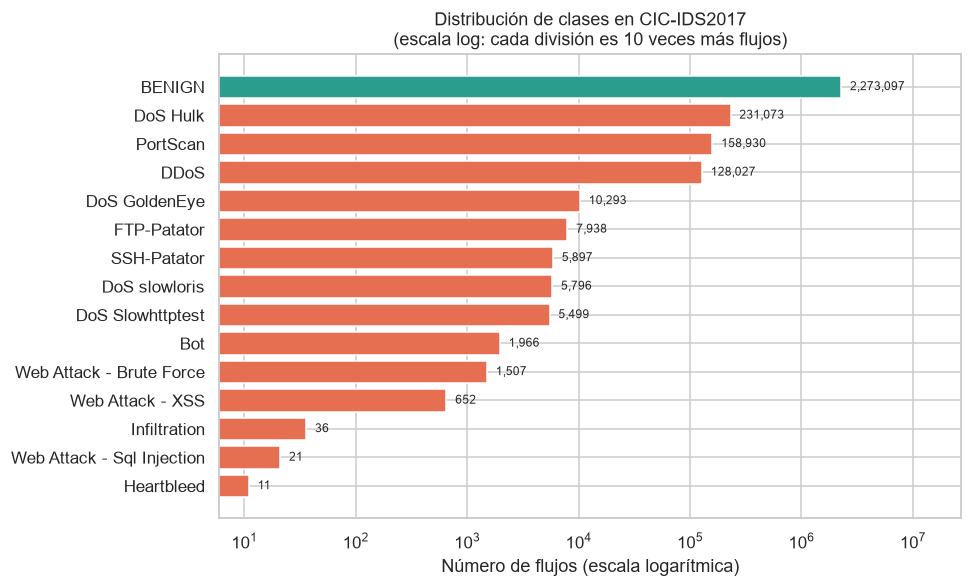

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = conteo.sort_values("flujos")
colores = ["#2a9d8f" if c == ETIQUETA_BENIGNA else "#e76f51" for c in orden.index]
ax.barh(orden.index, orden["flujos"], color=colores)
ax.set_xscale("log")
ax.set_xlabel("Número de flujos (escala logarítmica)")
ax.set_title("Distribución de clases en CIC-IDS2017\n(escala log: cada división es 10 veces más flujos)")
for i, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila["flujos"] * 1.2, i, f"{fila['flujos']:,.0f}", va="center", fontsize=8)
ax.set_xlim(right=conteo["flujos"].max() * 12)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "01_distribucion_clases.png", bbox_inches="tight")
plt.show()

**Lectura del desbalance.** El 80,3% del tráfico es normal y el 19,7% restante se
reparte de forma muy desigual entre los 14 ataques. Tres clases concentran casi todo el
ataque (DoS Hulk, PortScan y DDoS), y en el otro extremo hay tres clases con menos de
40 ejemplos en 2,8 millones de filas (Infiltration con 36, SQL Injection con 21 y
Heartbleed con 11). Esto tiene dos implicaciones directas:

- La **exactitud (accuracy) es engañosa**, porque un modelo que diga "todo es normal" acierta el 80%.
  Por eso hay que evaluar con métricas por clase (precisión, recall, F1).
- Las clases extremadamente raras **no alcanzan ni para una división train/test confiable**
  (con 11 casos, el test tendría 2 o 3), así que habrá que agruparlas o tratarlas aparte.

### ¿Cuándo ocurre cada ataque?

In [5]:
# Cada archivo corresponde a un día de la semana simulada.
dia_por_clase = pd.crosstab(df["archivo_origen"], df[COLUMNA_ETIQUETA])
print("Días (archivos) distintos en los que aparece cada clase:")
print((dia_por_clase > 0).sum().to_string())
dia_por_clase

Días (archivos) distintos en los que aparece cada clase:
Label
BENIGN                        8
Bot                           1
DDoS                          1
DoS GoldenEye                 1
DoS Hulk                      1
DoS Slowhttptest              1
DoS slowloris                 1
FTP-Patator                   1
Heartbleed                    1
Infiltration                  1
PortScan                      1
SSH-Patator                   1
Web Attack - Brute Force      1
Web Attack - Sql Injection    1
Web Attack - XSS              1


Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
archivo_origen,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,97718,0,128027,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,127537,0,0,0,0,0,0,0,0,0,158930,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX.csv,189067,1966,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX.csv,529918,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288566,0,0,0,0,0,0,0,0,36,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,168186,0,0,0,0,0,0,0,0,0,0,0,1507,21,652
Tuesday-WorkingHours.pcap_ISCX.csv,432074,0,0,0,0,0,0,7938,0,0,0,5897,0,0,0
Wednesday-workingHours.pcap_ISCX.csv,440031,0,0,10293,231073,5499,5796,0,11,0,0,0,0,0,0


**Hallazgo importante para la validación:** cada tipo de ataque ocurre en **un solo
día**, y el lunes es 100% tráfico normal. Esto tiene dos consecuencias:

- Para la clasificación multiclase no se puede validar entrenando con unos días y
  probando con otros, porque los ataques del día de prueba no existirían en el
  entrenamiento. Por eso las divisiones de los datos deben ser **aleatorias y
  estratificadas** por clase.
- El lunes (529.918 flujos, todos benignos) es un buen candidato para entrenar un
  modelo **no supervisado** solo con tráfico normal y probarlo en los demás días.

## 3. Calidad de datos

Aquí medimos las trampas conocidas del dataset: valores infinitos (Inf),
faltantes (NaN), negativos imposibles y filas duplicadas.

In [6]:
res = resumen_calidad(df.drop(columns=["archivo_origen"]))
print(f"Valores Inf:      {res['inf_total']:,}")
print(f"Valores NaN:      {res['nan_total']:,}")
print(f"Valores negativos:{res['negativos_total']:,}")
print(f"Filas duplicadas: {res['filas_duplicadas']:,} ({100 * res['filas_duplicadas'] / res['filas']:.2f}%)")

numericas = df.select_dtypes(include=[np.number])
filas_inf_nan = (np.isinf(numericas).any(axis=1) | df.isna().any(axis=1)).sum()
print(f"\nFilas con algún Inf o NaN: {filas_inf_nan:,} ({100 * filas_inf_nan / len(df):.3f}% del total)")

pd.DataFrame({"Inf": res["inf_por_columna"], "NaN": res["nan_por_columna"]}).fillna(0).astype(int)

Valores Inf:      4,376
Valores NaN:      1,358
Valores negativos:2,446,286
Filas duplicadas: 330,995 (11.69%)



Filas con algún Inf o NaN: 2,867 (0.101% del total)


,Inf,NaN
Flow Bytes/s,1509,1358
Flow Packets/s,2867,0


In [7]:
print("Valores negativos por columna:")
print(res["negativos_por_columna"].to_string())

neg_fwd = df.loc[df["Init_Win_bytes_forward"] < 0, "Init_Win_bytes_forward"].unique()
neg_bwd = df.loc[df["Init_Win_bytes_backward"] < 0, "Init_Win_bytes_backward"].unique()
print(f"\nValores negativos únicos en Init_Win_bytes_forward:  {neg_fwd}")
print(f"Valores negativos únicos en Init_Win_bytes_backward: {neg_bwd}")
print(f"Flujos con duración negativa (imposible físicamente): {(df['Flow Duration'] < 0).sum():,}")

Valores negativos por columna:
Init_Win_bytes_backward    1441552
Init_Win_bytes_forward     1001189
Flow IAT Min                  2891
Flow Duration                  115
Flow Packets/s                 115
Flow IAT Mean                  115
Flow IAT Max                   115
Flow Bytes/s                    85
min_seg_size_forward            35
Fwd Header Length               35
Bwd Header Length               22
Fwd IAT Min                     17

Valores negativos únicos en Init_Win_bytes_forward:  [-1]
Valores negativos únicos en Init_Win_bytes_backward: [-1]
Flujos con duración negativa (imposible físicamente): 115


**Lectura de la calidad.** Encontramos tres problemas muy distintos entre sí:

1. **Inf/NaN (0,10% de las filas).** Se concentran en `Flow Bytes/s` y `Flow Packets/s`,
   que se calculan dividiendo entre la duración del flujo, y esa duración a veces es 0.
   El impacto es mínimo y se pueden eliminar o imputar sin afectar el análisis.
2. **Negativos.** Los ~2,4M de negativos en `Init_Win_bytes_forward/backward` (1,44M en una
   columna y 1,00M en la otra) son **todos el valor −1**, un código que usa la herramienta de captura para decir
   "no aplica". Por eso hay que tratarlo como un valor especial y no como una medida.
   Aparte de esto, 115 flujos tienen **duración negativa**, que sí es un error de
   captura (0,004%).
3. **Duplicados (11,7%).** Son filas idénticas en las 78 columnas y representan un riesgo
   metodológico: si una misma fila cae en entrenamiento y en prueba, el modelo "acierta"
   porque la memorizó (fuga de información). La siguiente celda muestra qué clases
   perderían más ejemplos al quitar los duplicados.

In [8]:
mascara_dup = df.drop(columns=["archivo_origen"]).duplicated()
impacto = pd.DataFrame(
    {
        "flujos_originales": df[COLUMNA_ETIQUETA].value_counts(),
        "flujos_sin_duplicados": df.loc[~mascara_dup, COLUMNA_ETIQUETA].value_counts(),
    }
)
impacto["se_perderia_pct"] = (
    100 * (1 - impacto["flujos_sin_duplicados"] / impacto["flujos_originales"])
).round(1)
impacto

,flujos_originales,flujos_sin_duplicados,se_perderia_pct
Label,,,
BENIGN,2273097,2073870,8.8
Bot,1966,1953,0.7
DDoS,128027,128016,0.0
DoS GoldenEye,10293,10286,0.1
DoS Hulk,231073,172849,25.2
DoS Slowhttptest,5499,5228,4.9
DoS slowloris,5796,5385,7.1
FTP-Patator,7938,5933,25.3
Heartbleed,11,11,0.0


Quitar los duplicados afecta sobre todo a SSH-Patator (pierde el 45%), PortScan (43%),
FTP-Patator y DoS Hulk (25%), que son ataques automatizados que generan muchos flujos
idénticos. Las clases extremadamente raras no pierden ni un caso. Es un costo aceptable
a cambio de evitar la fuga de información, pero la decisión se toma después de revisar
este EDA.

## 4. Features: estadísticas, varianza cero y redundancia

In [9]:
# Estadísticas descriptivas de las 77 features numéricas
estadisticas = numericas.describe(percentiles=[0.5]).T
estadisticas = estadisticas.rename(
    columns={"count": "n", "mean": "media", "std": "desv_est",
             "min": "mínimo", "50%": "mediana", "max": "máximo"}
)
estadisticas[["media", "desv_est", "mínimo", "mediana", "máximo"]].round(2)

,media,desv_est,mínimo,mediana,máximo
Destination Port,8071.48,18283.63,0.0,80.0,65535.0
Flow Duration,14785663.93,33653744.09,-13.0,31316.0,119999998.0
Total Fwd Packets,9.36,749.67,1.0,2.0,219759.0
Total Backward Packets,10.39,997.39,0.0,2.0,291922.0
Total Length of Fwd Packets,549.30,9993.59,0.0,62.0,12900000.0
...,...,...,...,...,...
Active Min,58295.82,577092.28,0.0,0.0,110000000.0
Idle Mean,8316037.50,23630078.00,0.0,0.0,120000000.0
Idle Std,503843.91,4602984.50,0.0,0.0,76900000.0
Idle Max,8695751.98,24366888.33,0.0,0.0,120000000.0


In [10]:
# Features constantes: tienen el mismo valor en todas las filas, así que no aportan información
n_unicos = numericas.nunique()
varianza_cero = n_unicos[n_unicos <= 1].index.tolist()
print(f"Features con varianza cero ({len(varianza_cero)} de {numericas.shape[1]}):")
for col in varianza_cero:
    print(f"  - {col} (valor único: {df[col].iloc[0]})")

Features con varianza cero (8 de 77):
  - Bwd PSH Flags (valor único: 0)
  - Bwd URG Flags (valor único: 0)
  - Fwd Avg Bytes/Bulk (valor único: 0)
  - Fwd Avg Packets/Bulk (valor único: 0)
  - Fwd Avg Bulk Rate (valor único: 0)
  - Bwd Avg Bytes/Bulk (valor único: 0)
  - Bwd Avg Packets/Bulk (valor único: 0)
  - Bwd Avg Bulk Rate (valor único: 0)


In [11]:
# Correlaciones entre features (sobre una muestra de 300.000 flujos para que sea más rápido).
muestra = df.sample(n=300_000, random_state=RANDOM_STATE)
num_muestra = (
    muestra.select_dtypes(include=[np.number])
    .drop(columns=varianza_cero)
    .replace([np.inf, -np.inf], np.nan)
)
correlacion = num_muestra.corr().abs()
pares = (
    correlacion.where(np.triu(np.ones(correlacion.shape, dtype=bool), k=1))
    .stack()
    .sort_values(ascending=False)
)
pares_altos = pares[pares > 0.95]
cols_en_pares = {c for par in pares_altos.index for c in par}
print(f"Pares de features con |correlación| > 0.95: {len(pares_altos)}")
print(f"Features involucradas en algún par redundante: {len(cols_en_pares)} de {num_muestra.shape[1]}")
pares_altos.head(12).to_frame("correlación_absoluta").round(4)

Pares de features con |correlación| > 0.95: 51
Features involucradas en algún par redundante: 37 de 69


,,correlación_absoluta
Fwd URG Flags,CWE Flag Count,1.0000
Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000
Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000
Fwd PSH Flags,SYN Flag Count,1.0000
RST Flag Count,ECE Flag Count,1.0000
Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000
Total Backward Packets,Subflow Bwd Packets,1.0000
Total Fwd Packets,Subflow Fwd Packets,1.0000
Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000
Total Fwd Packets,Total Length of Bwd Packets,0.9997


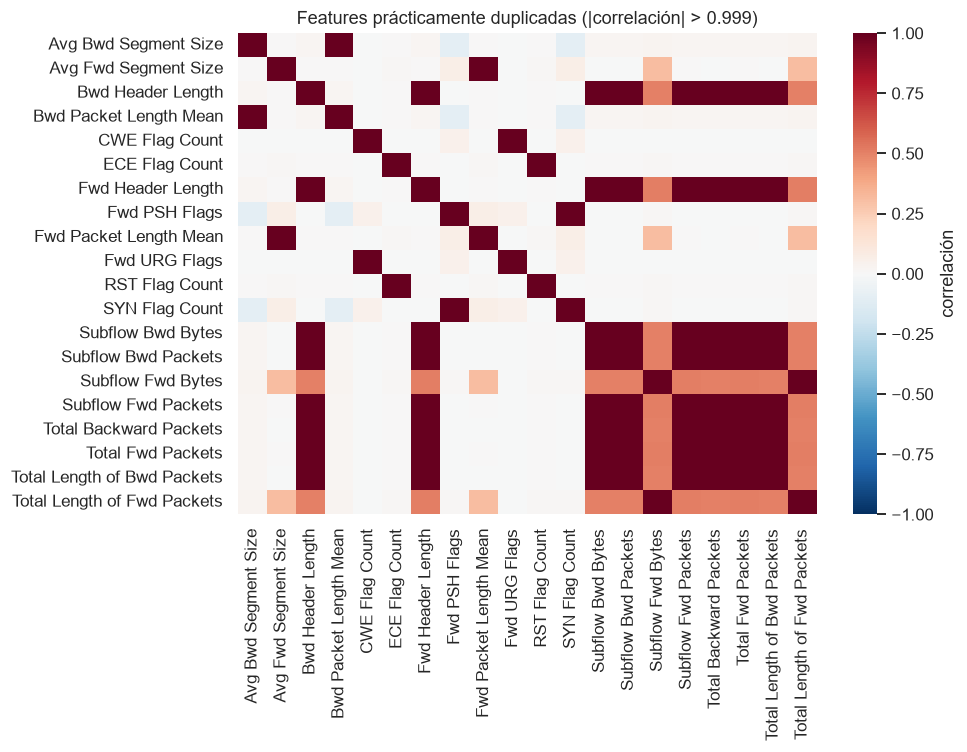

In [12]:
# Heatmap de las features que están prácticamente duplicadas (correlación cercana a 1)
cols_redundantes = sorted({c for par in pares_altos[pares_altos > 0.999].index for c in par})
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    num_muestra[cols_redundantes].corr(),
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=len(cols_redundantes) <= 12, fmt=".2f",
    ax=ax, cbar_kws={"label": "correlación"},
)
ax.set_title("Features prácticamente duplicadas (|correlación| > 0.999)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "02_correlaciones_redundantes.png", bbox_inches="tight")
plt.show()

**Lectura de la redundancia.** Hay grupos de columnas que miden lo mismo con otro
nombre (por ejemplo, `Subflow Fwd Bytes` es igual a `Total Length of Fwd Packets`, y
`Avg Fwd Segment Size` es igual a `Fwd Packet Length Mean`), además de 8 columnas
constantes. Para el modelado esto significa que las ~77 features se pueden reducir a
**unas 40-50 sin perder información**, lo que también simplifica la interpretación
(dos features idénticas se "reparten" la importancia y confunden la lectura).

## 5. Primeras señales: ¿el tráfico de ataque se ve distinto?

Esta comparación es solo descriptiva (todavía no hay ningún modelo) y muestra la
distribución de cuatro features en el tráfico normal y en el de ataque, en escala
logarítmica.

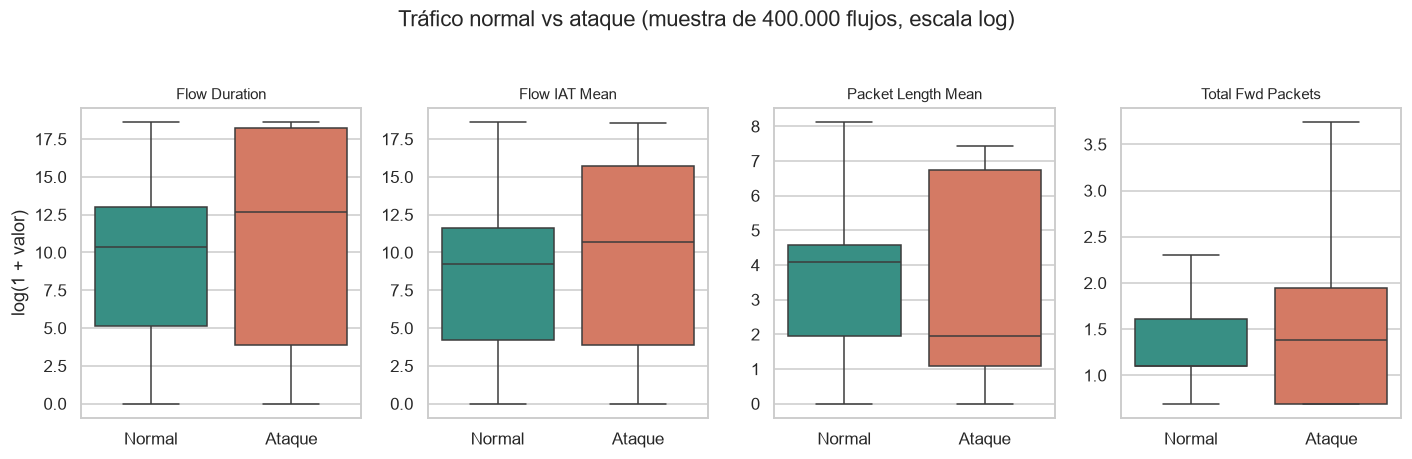

In [13]:
features_ejemplo = ["Flow Duration", "Flow IAT Mean", "Packet Length Mean", "Total Fwd Packets"]

df["tipo"] = np.where(df[COLUMNA_ETIQUETA] == ETIQUETA_BENIGNA, "Normal", "Ataque")
muestra_v = df.sample(n=400_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, feat in zip(axes, features_ejemplo):
    datos = muestra_v[[feat, "tipo"]].copy()
    datos["valor_log"] = np.log1p(datos[feat].clip(lower=0))
    sns.boxplot(
        data=datos, x="tipo", y="valor_log", hue="tipo",
        order=["Normal", "Ataque"], hue_order=["Normal", "Ataque"],
        palette={"Normal": "#2a9d8f", "Ataque": "#e76f51"},
        showfliers=False, legend=False, ax=ax,
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("log(1 + valor)" if feat == features_ejemplo[0] else "")
fig.suptitle("Tráfico normal vs ataque (muestra de 400.000 flujos, escala log)", y=1.04)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "03_normal_vs_ataque_features.png", bbox_inches="tight")
plt.show()
df = df.drop(columns=["tipo"])

Se ven diferencias claras en la mediana y en la dispersión de varias features (los
ataques tienden a durar distinto y a tener otros ritmos de paquetes), pero también hay
un **solapamiento importante**: ninguna feature separa por sí sola el tráfico malicioso.
Este es justo el escenario en el que un modelo que combina varias features aporta valor,
y sugiere que la pregunta de interpretabilidad ("¿qué features distinguen un ataque?")
tiene sustento en los datos.

## 6. Conclusiones del EDA

**Volumen y estructura**
- 2.830.743 flujos, 77 features numéricas y la etiqueta; 8 archivos con el mismo esquema.
- Consolidado en Parquet: pasa de 1.834 MB a 664 MB en RAM (float32) y ocupa 255 MB en disco.

**Desbalance (severo, en dos niveles)**
- Binario: 80,3% normal y 19,7% ataque (manejable con técnicas estándar).
- Multiclase: va de 231.073 casos (DoS Hulk) a 11 (Heartbleed), con una razón de
  206.645 a 1 frente a BENIGN. Infiltration (36), SQL Injection (21) y Heartbleed (11)
  no alcanzan para tener métricas por clase confiables.

**Calidad**
- Inf/NaN: 2.867 filas (0,10%), concentradas en 2 features de tasa. El impacto es bajo.
- Negativos: el −1 se usa como código de "no aplica" en `Init_Win_bytes_*` (hay que
  tratarlo como un valor especial); hay 115 duraciones negativas (son errores y se eliminan).
- Duplicados: 330.995 filas (11,7%). Quitarlos es necesario para evitar la fuga de
  información, aunque el costo no es igual para todas las clases (SSH-Patator pierde
  el 45% y PortScan el 43%).

**Features**
- 8 constantes (se eliminan) y 37 que aparecen en pares con |r| > 0,95 (se pueden
  podar a unas 40-50 features efectivas, lo que facilita la interpretación).

**Diseño de validación**
- Cada ataque ocurre en un solo día, así que para el problema supervisado las divisiones
  de los datos deben ser aleatorias y estratificadas. El lunes, que es 100% benigno,
  permite probar el enfoque no supervisado.
- Limitación que hay que documentar: la literatura reporta errores de etiquetado en
  este dataset (Engelen 2021; Lanvin 2023; Rosay 2022). Está explicada en los
  riesgos del reporte técnico (`reports/reporte_tecnico_final.pdf`, sección 8.3).

**Siguiente paso:** revisar las preguntas de negocio (están en la sección 2.1 del
reporte técnico, en el Cuadro 1) y aprobar las preguntas y las decisiones de limpieza
antes de empezar a modelar.